# Load NetCDF file from a seachable STAC catalog

This notebook shows an example how to load a NetCDF file from a searchable STAC catalog.

A searchable catalog implements the [STAC API - Item Search](https://github.com/radiantearth/stac-api-spec/tree/release/v1.0.0/item-search) conformance class, which provides the ability to search for STAC Item objects across collections.

### Setup
In order to run this notebook you need to install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac). You may install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac) directly from the git repository by cloning the repository, directing into `xcube-stac`, and following the steps below:

```bash
conda env create -f environment.yml
conda activate xcube-stac
pip install .
```

Note that [`xcube_stac`](https://github.com/xcube-dev/xcube-stac) is a plugin of [`xcube`](https://xcube.readthedocs.io/en/latest/), where `xcube` is included in the `environment.yml`.  

Now, we first import everything we need:

In [1]:
%%time
from xcube.core.store import new_data_store, get_data_store_params_schema
import itertools

CPU times: user 3.66 s, sys: 377 ms, total: 4.04 s
Wall time: 2.18 s


First, we get the store parameters needed to initialize a STAC [data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework). 

In [2]:
%%time
store_params = get_data_store_params_schema("stac")
store_params

CPU times: user 455 ms, sys: 35.3 ms, total: 490 ms
Wall time: 487 ms


We determine the url of the STAC catalog of the [DLR's Earth Observation Center (EOC)](https://geoservice.dlr.de/eoc/ogc/stac/v1/)  and initiate a STAC [data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework) where the `xcube-stac` plugin is recognized by setting the first argument to `"stac"` in the `new_data_store` function.

In [3]:
url = "https://geoservice.dlr.de/eoc/ogc/stac/v1"
store = new_data_store("stac", url=url)

The data IDs point to a [STAC item's JSON](https://github.com/radiantearth/stac-spec/blob/master/item-spec/item-spec.md) and are specified by the segment of the URL that follows the catalog's URL. The data IDs can be streamed using the following code where we show the first 10 data IDs as an example.

In [4]:
%%time
data_ids = store.get_data_ids()
list(itertools.islice(data_ids, 10))

CPU times: user 31.2 ms, sys: 12.4 ms, total: 43.6 ms
Wall time: 2.25 s


['collections/S5P_TROPOMI_L3_P1D_CF/items/S5P_DLR_NRTI_01_040201_L3_CF_20240619?f=application%2Fgeo%2Bjson',
 'collections/S5P_TROPOMI_L3_P1D_COT/items/S5P_DLR_NRTI_01_040201_L3_COT_20240619?f=application%2Fgeo%2Bjson',
 'collections/S5P_TROPOMI_L3_P1D_CTH/items/S5P_DLR_NRTI_01_040201_L3_CTH_20240619?f=application%2Fgeo%2Bjson',
 'collections/S5P_TROPOMI_L3_P1D_HCHO/items/S5P_DLR_NRTI_01_040201_L3_HCHO_20240619?f=application%2Fgeo%2Bjson',
 'collections/S5P_TROPOMI_L3_P1D_O3/items/S5P_DLR_NRTI_01_040201_L3_O3_20240619?f=application%2Fgeo%2Bjson',
 'collections/S5P_TROPOMI_L3_P1D_SO2/items/S5P_DLR_NRTI_01_040201_L3_SO2_20240619?f=application%2Fgeo%2Bjson',
 'collections/ENMAP_HSI_L2A/items/ENMAP01-____L2A-DT0000078315_20240618T080348Z_002_V010402_20240619T042959Z?f=application%2Fgeo%2Bjson',
 'collections/ENMAP_HSI_L2A/items/ENMAP01-____L2A-DT0000078315_20240618T080344Z_001_V010402_20240619T042955Z?f=application%2Fgeo%2Bjson',
 'collections/ENMAP_HSI_L2A/items/ENMAP01-____L2A-DT00000798

In the next step, we can search for items using search parameters. The following code shows which search parameters are available.

In [5]:
%%time
search_params = store.get_search_params_schema()
search_params

CPU times: user 23 µs, sys: 3 µs, total: 26 µs
Wall time: 28.6 µs


Now, let's search for Sentinel-5P TROPOMI L3 Data of radiometric cloud fraction variable data (`S5P_TROPOMI_L3_P1D_CF`) for 18. June and 19. June 2024. Note that [item S5P_DLR_NRTI_01_040201_L3_CF_20240619](https://geoservice.dlr.de/eoc/ogc/stac/v1/collections/S5P_TROPOMI_L3_P1D_CF/items/S5P_DLR_NRTI_01_040201_L3_CF_20240619) covers the entire globe. We thus do not assign any `bbox` here. 

In [6]:
%%time
descriptors = list(
    store.search_data(
        collections=["S5P_TROPOMI_L3_P1D_CF"],
        time_range=["2024-06-18", "2024-06-20"],
    )
)
[d.to_dict() for d in descriptors]

CPU times: user 63.7 ms, sys: 535 µs, total: 64.3 ms
Wall time: 2.44 s


[{'data_id': 'collections/S5P_TROPOMI_L3_P1D_CF/items/S5P_DLR_NRTI_01_040201_L3_CF_20240619?f=application%2Fgeo%2Bjson',
  'data_type': 'dataset',
  'bbox': [-180.0, -90.0, 180.0, 90.0],
  'time_range': ['2024-06-19', None]},
 {'data_id': 'collections/S5P_TROPOMI_L3_P1D_CF/items/S5P_DLR_NRTI_01_040201_L3_CF_20240618?f=application%2Fgeo%2Bjson',
  'data_type': 'dataset',
  'bbox': [-180.0, -90.0, 180.0, 90.0],
  'time_range': ['2024-06-18', None]}]

In the next step, we can open the data for each data ID. The following code shows which parameters are available for opening the data.

In [7]:
%%time
open_params = store.get_open_data_params_schema()
open_params

CPU times: user 63 µs, sys: 8 µs, total: 71 µs
Wall time: 77.5 µs


We select the asset data, as this is the only asset, which links to a netcdf file, when investigating the [item S5P_DLR_NRTI_01_040201_L3_CF_20240619](https://geoservice.dlr.de/eoc/ogc/stac/v1/collections/S5P_TROPOMI_L3_P1D_CF/items/S5P_DLR_NRTI_01_040201_L3_CF_20240619).

In [8]:
%%time
ds = store.open_data(descriptors[1].data_id, asset_names=["data"])
ds

CPU times: user 194 ms, sys: 33.8 ms, total: 228 ms
Wall time: 3.19 s


<xarray.Dataset> Size: 130MB
Dimensions:                                    (lat: 1800, lon: 3600)
Coordinates:
  * lat                                        (lat) float32 7kB -89.95 ... 8...
  * lon                                        (lon) float32 14kB -179.9 ... ...
Data variables:
    data_radiometric_cloud_fraction            (lat, lon) float32 26MB dask.array<chunksize=(900, 1800), meta=np.ndarray>
    data_radiometric_cloud_fraction_precision  (lat, lon) float32 26MB dask.array<chunksize=(900, 1800), meta=np.ndarray>
    data_number_of_observations                (lat, lon) float64 52MB dask.array<chunksize=(900, 1800), meta=np.ndarray>
    data_quality_flag                          (lat, lon) float32 26MB dask.array<chunksize=(1800, 3600), meta=np.ndarray>

We plot the loaded data as an example below.

CPU times: user 1.79 s, sys: 356 ms, total: 2.15 s
Wall time: 4.92 s


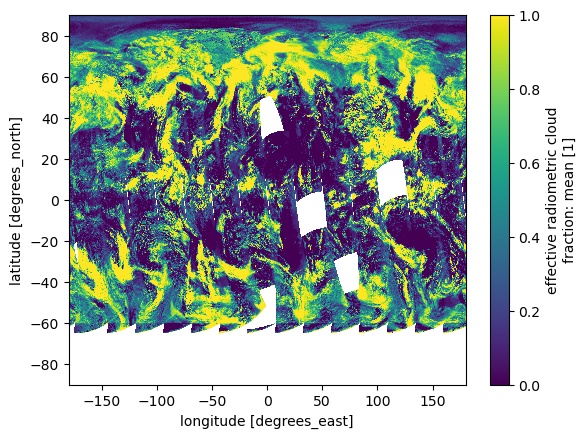

In [9]:
%%time
ds.data_radiometric_cloud_fraction.plot()